In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import re


In [140]:
def plot_count(cdict,descr=None,logscale=False):
    '''simple function to plot a count of punctation expressions encoded
     in the form aof a dictionary'''
    fig, ax = plt.subplots()
    if descr:
        ax.bar(descr.values(), cdict.values(), width=0.8)
    else: 
        ax.bar(cdict.keys(), cdict.values(), width=0.8)
    ax.set_xlabel("Punctuation Mark")
    ax.set_ylabel("Absolute Frequency")
    ax.set_title("Absolute Frequency of Punctuation Marks")
    if descr:
        ax.set_xticklabels(labels=descr.values(),rotation=30,ha='right')
    if logscale:
        ax.set_yscale('log')

    # Display the plot
    plt.show()

    # Print the counts
    for mark, count in cdict.items():
        print(f"The absolute frequency of '{mark}' is: {count}")

In [141]:

# Load the comments data into a pandas DataFrame
df = pd.read_csv('raw_data/bookscirclejerk.csv')

In [142]:
def count_punct2(df:pd.DataFrame,marks):
    '''in this function marks is a list, each item can also be a regular expression
    df: Pandas dataframe
    marks: list of expressions'''
    count_dict={}
    for mark in marks:
        count = df['body'].str.count(mark).sum()
        count_dict[mark]=count
    return count_dict

In [143]:
#Il formato è: {'regexp': 'descrizione'}

#(la descrizione serve eventualmente per il plot)

In [144]:
marks={'!! ':'exclamation point followed by whitespace',"!!": 'double exl', "\?\?": 'double question marks', "\?!": 'question mark and exl',
 "!\?": 'asdasad', "\.\.\.\.": 'four points', '!!! ':'three exclamation marks','!!!!':'four exclamation marks', '!!+':'2 or more exclamation marks','[\U0001f600-\U0001f650]':'emoji'}


In [151]:
count_2=count_punct2(df,marks.keys())


In [146]:
#counts={}

In [147]:
def count_punct_3(df:pd.DataFrame,marks_dict:dict):
    count_dict={}
    for pattern in marks_dict.keys():
        #print(pattern)
        try:
            regex = re.compile(pattern)
            df[pattern] = df['body'].apply(lambda x: len(regex.findall(x)))
            count_dict[pattern]=df[pattern].sum()
        except:
            print(pattern, ' is not a regular expression.\n')
            '''non-regex method'''
            count = df['body'].str.count(pattern).sum()
            count_dict[pattern]=count
    return count_dict

In [148]:
count3=count_punct_3(df,marks)

c:\Users\Alessandro\anaconda3\envs\tf\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128592 (\N{NORTH WEST POINTING LEAF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


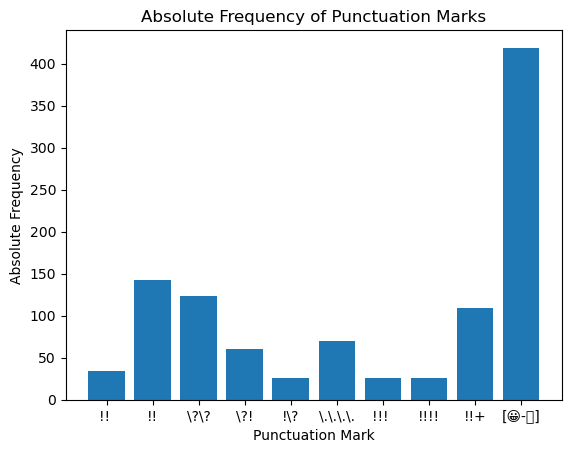

The absolute frequency of '!! ' is: 34
The absolute frequency of '!!' is: 142
The absolute frequency of '\?\?' is: 123
The absolute frequency of '\?!' is: 60
The absolute frequency of '!\?' is: 26
The absolute frequency of '\.\.\.\.' is: 70
The absolute frequency of '!!! ' is: 26
The absolute frequency of '!!!!' is: 26
The absolute frequency of '!!+' is: 109
The absolute frequency of '[😀-🙐]' is: 419


In [149]:
plot_count(count_2)

C:\Users\Alessandro\AppData\Local\Temp\ipykernel_5368\3313380576.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels=descr.values(),rotation=30,ha='right')


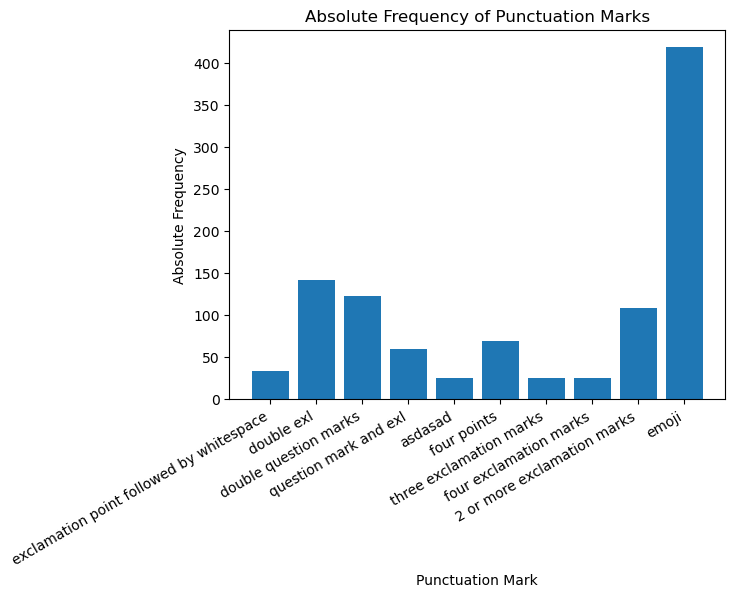

The absolute frequency of '!! ' is: 34
The absolute frequency of '!!' is: 142
The absolute frequency of '\?\?' is: 123
The absolute frequency of '\?!' is: 60
The absolute frequency of '!\?' is: 26
The absolute frequency of '\.\.\.\.' is: 70
The absolute frequency of '!!! ' is: 26
The absolute frequency of '!!!!' is: 26
The absolute frequency of '!!+' is: 109
The absolute frequency of '[😀-🙐]' is: 419


In [150]:
plot_count(count3,descr=marks)